In [1]:
!pip install nbformat

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Load dataset
df = sns.load_dataset('titanic')[['fare', 'age', 'survived']].dropna()

X = df[['fare', 'age']].values
y = df['survived'].values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X_scaled.shape)
print("y shape:", y.shape)

X shape: (714, 2)
y shape: (714,)


In [35]:
# 5 sigmoid layers one by one
model_sigmoid = Sequential()
model_sigmoid.add(Dense(8, activation='sigmoid', input_shape=(2,)))
model_sigmoid.add(Dense(8, activation='sigmoid'))
model_sigmoid.add(Dense(8, activation='sigmoid'))
model_sigmoid.add(Dense(8, activation='sigmoid'))
model_sigmoid.add(Dense(8, activation='sigmoid'))
model_sigmoid.add(Dense(1, activation='sigmoid'))  # output

model_sigmoid.compile(optimizer='sgd',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

history_sigmoid = model_sigmoid.fit(X_scaled, y,
                                     epochs=20,
                                     batch_size=32,
                                     verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6022 - loss: 0.7266   
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5821 - loss: 0.7321 
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5917 - loss: 0.7112 
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6144 - loss: 0.6833 
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6085 - loss: 0.6826
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5880 - loss: 0.6938
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5995 - loss: 0.6823 
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5856 - loss: 0.6884 
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5932 - loss: 0.6814 
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5721 - loss: 0.6921 
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6058 - loss: 0.6721 
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5863 - lo


SGD    →  simple, slow, shows vanishing
          gradient problem CLEARLY ✅

Adam   →  too smart, fixes gradient
          problems automatically
          vanishing gradient gets HIDDEN ❌


In [36]:
# collect all weight means in a simple list

sig_weights  = []
relu_weights = []

for layer in model_sigmoid.layers:
    w = layer.get_weights()
    if w:
        sig_weights.append(np.mean(np.abs(w[0])))

for layer in model_relu.layers:
    w = layer.get_weights()
    if w:
        relu_weights.append(np.mean(np.abs(w[0])))

print("Sigmoid weights:", sig_weights)
print("ReLU    weights:", relu_weights)

Sigmoid weights: [np.float32(0.31382272), np.float32(0.26489922), np.float32(0.28899017), np.float32(0.31416962), np.float32(0.32367814), np.float32(0.34357253)]
ReLU    weights: [np.float32(0.28547508), np.float32(0.29672584), np.float32(0.2496267), np.float32(0.26213372), np.float32(0.30768424), np.float32(0.4416604)]


In [38]:
# ── SIGMOID GRADIENTS ─────────────────────────────────────

X_t = tf.constant(X_scaled[:32], dtype=tf.float32)
y_t = tf.constant(y[:32],        dtype=tf.float32)

with tf.GradientTape() as tape:
    pred = model_sigmoid(X_t, training=True)
    loss = tf.keras.losses.binary_crossentropy(
               y_t, tf.squeeze(pred))

grads_sigmoid = tape.gradient(
    loss, model_sigmoid.trainable_variables)

print("==== SIGMOID GRADIENTS ====")
for i in range(0, len(grads_sigmoid), 2):
    val = np.mean(np.abs(grads_sigmoid[i].numpy()))
    print("Layer", i//2+1, "=", val)


# ── RELU GRADIENTS ────────────────────────────────────────

with tf.GradientTape() as tape:
    pred = model_relu(X_t, training=True)
    loss = tf.keras.losses.binary_crossentropy(
               y_t, tf.squeeze(pred))

grads_relu = tape.gradient(
    loss, model_relu.trainable_variables)

print()
print("==== RELU GRADIENTS ====")
for i in range(0, len(grads_relu), 2):
    val = np.mean(np.abs(grads_relu[i].numpy()))
    print("Layer", i//2+1, "=", val)

==== SIGMOID GRADIENTS ====
Layer 1 = 4.0644104e-06
Layer 2 = 3.0775655e-06
Layer 3 = 2.0074891e-05
Layer 4 = 9.172492e-05
Layer 5 = 0.0004046801
Layer 6 = 0.0038647682

==== RELU GRADIENTS ====
Layer 1 = 0.004491263
Layer 2 = 0.0018428288
Layer 3 = 0.0028593168
Layer 4 = 0.0025862833
Layer 5 = 0.0008326322
Layer 6 = 0.0011861853


In [41]:
# collect weights after each epoch
# we need to retrain and save weights each epoch

sig_weights_per_epoch  = []
relu_weights_per_epoch = []

# reset and retrain sigmoid saving weights
model_sigmoid2 = Sequential()
model_sigmoid2.add(Dense(8, activation='sigmoid', input_shape=(2,)))
model_sigmoid2.add(Dense(8, activation='sigmoid'))
model_sigmoid2.add(Dense(8, activation='sigmoid'))
model_sigmoid2.add(Dense(8, activation='sigmoid'))
model_sigmoid2.add(Dense(8, activation='sigmoid'))
model_sigmoid2.add(Dense(1, activation='sigmoid'))
model_sigmoid2.compile(optimizer='sgd',
                        loss='binary_crossentropy')

# reset and retrain relu saving weights
model_relu2 = Sequential()
model_relu2.add(Dense(8, activation='relu', input_shape=(2,)))
model_relu2.add(Dense(8, activation='relu'))
model_relu2.add(Dense(8, activation='relu'))
model_relu2.add(Dense(8, activation='relu'))
model_relu2.add(Dense(8, activation='relu'))
model_relu2.add(Dense(1, activation='sigmoid'))
model_relu2.compile(optimizer='sgd',
                     loss='binary_crossentropy')


# train 1 epoch at a time and save weight mean
for epoch in range(20):

    model_sigmoid2.fit(X_scaled, y,
                       epochs=1,
                       batch_size=32,
                       verbose=0)

    model_relu2.fit(X_scaled, y,
                    epochs=1,
                    batch_size=32,
                    verbose=0)

    # save first layer weight mean only
    w_sig  = model_sigmoid2.layers[0].get_weights()[0]
    w_relu = model_relu2.layers[0].get_weights()[0]

    sig_weights_per_epoch.append(np.mean(np.abs(w_sig)))
    relu_weights_per_epoch.append(np.mean(np.abs(w_relu)))
    print("Epoch", epoch+1, "done")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done
Epoch 9 done
Epoch 10 done
Epoch 11 done
Epoch 12 done
Epoch 13 done
Epoch 14 done
Epoch 15 done
Epoch 16 done
Epoch 17 done
Epoch 18 done
Epoch 19 done
Epoch 20 done


In [42]:
# collect gradient values for bar chart
sig_grads  = []
relu_grads = []

for i in range(0, len(grads_sigmoid), 2):
    sig_grads.append(np.mean(np.abs(grads_sigmoid[i].numpy())))

for i in range(0, len(grads_relu), 2):
    relu_grads.append(np.mean(np.abs(grads_relu[i].numpy())))

layers = ["L1","L2","L3","L4","L5","L6"]

/tmp/ipykernel_1035/884244234.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1035/884244234.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


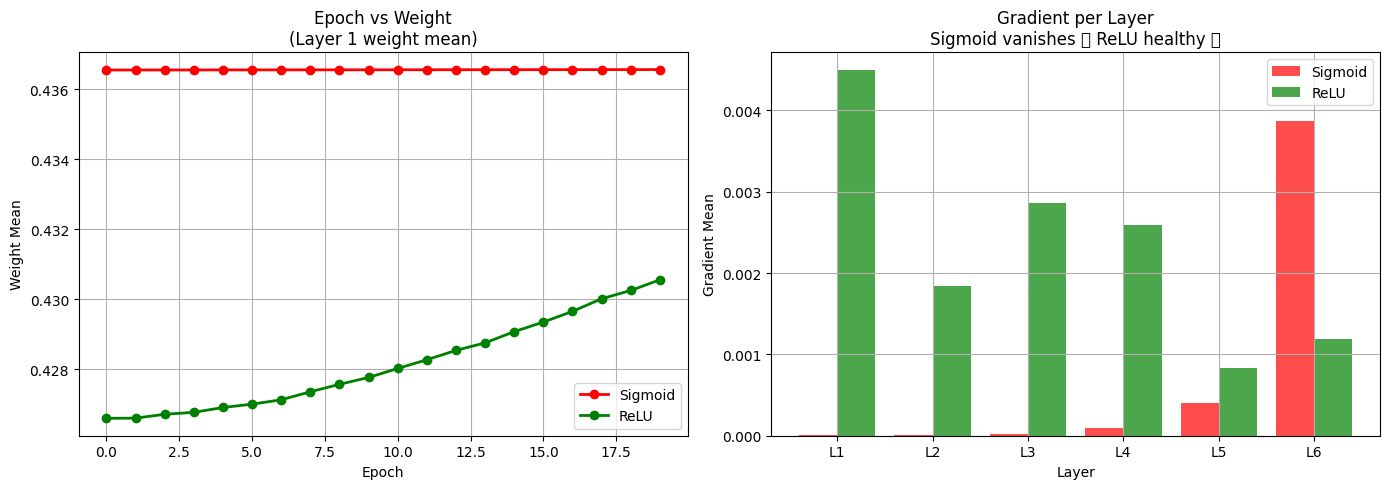

In [43]:
plt.figure(figsize=(14, 5))

# ── Graph 1: Epoch vs Weight ──────────────────────────────
plt.subplot(1, 2, 1)
plt.plot(sig_weights_per_epoch,
         'r-o', linewidth=2, label='Sigmoid')
plt.plot(relu_weights_per_epoch,
         'g-o', linewidth=2, label='ReLU')
plt.title('Epoch vs Weight\n(Layer 1 weight mean)')
plt.xlabel('Epoch')
plt.ylabel('Weight Mean')
plt.legend()
plt.grid(True)

# ── Graph 2: Gradient Relu vs Sigmoid ────────────────────
plt.subplot(1, 2, 2)
x = np.arange(len(layers))
plt.bar(x - 0.2, sig_grads,  0.4,
        color='red',   alpha=0.7, label='Sigmoid')
plt.bar(x + 0.2, relu_grads, 0.4,
        color='green', alpha=0.7, label='ReLU')
plt.title('Gradient per Layer\nSigmoid vanishes ❌ ReLU healthy ✅')
plt.xlabel('Layer')
plt.ylabel('Gradient Mean')
plt.xticks(x, layers)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
